575.38


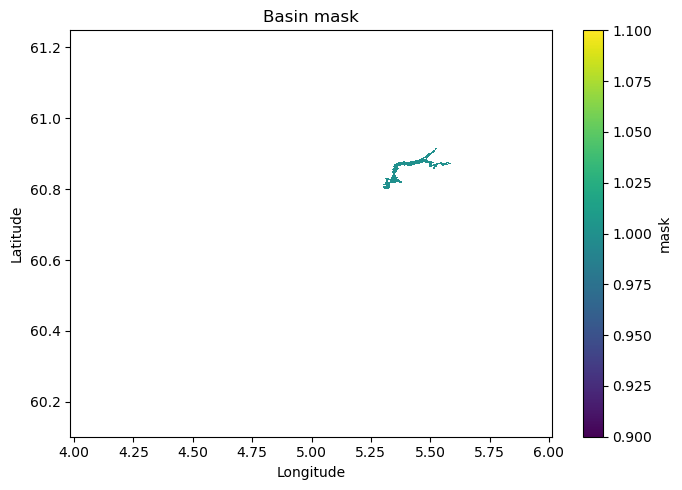

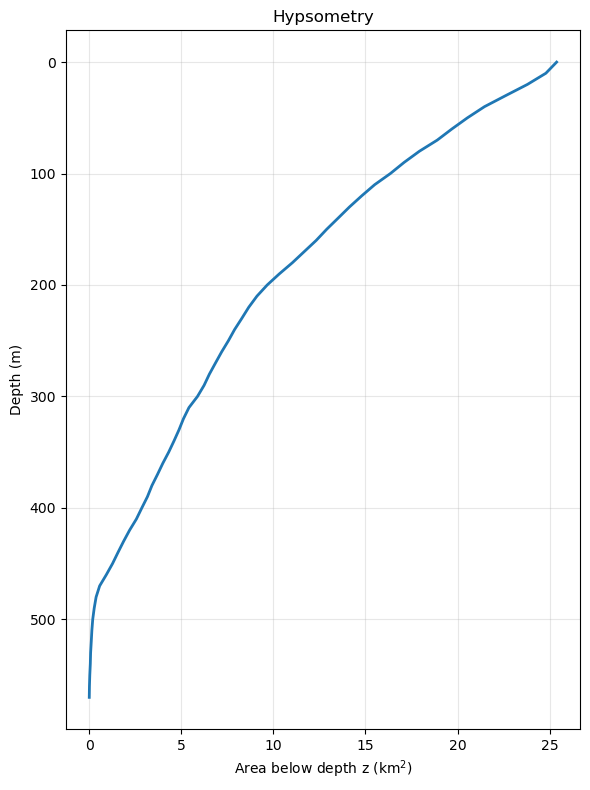

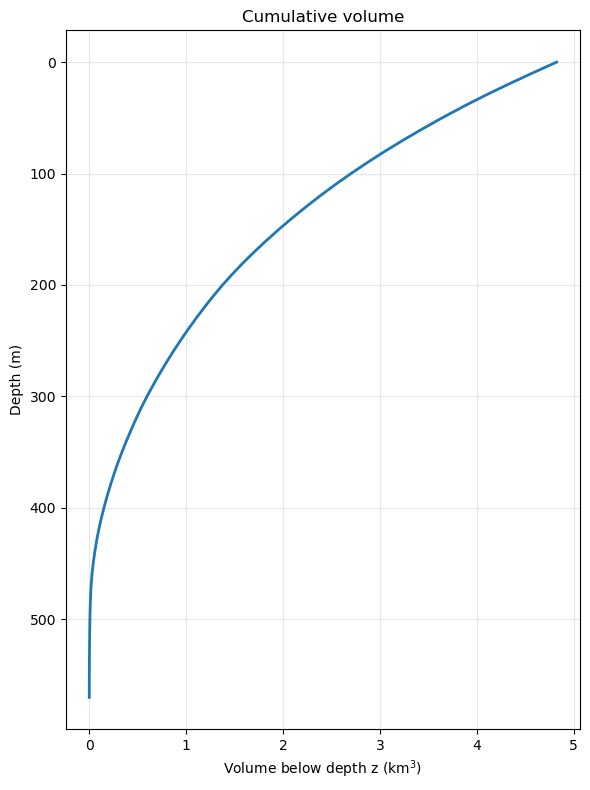

===== Hypsometry calculation completed =====
bathymetry file: C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\highres_bathy.npy
output directory: C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report
dz = 10.0 m
sill_lon = 5.3
Maximum depth: 1401.7 m
A(0) = 25.376 km^2
V(0) = 4.823 km^3
CSV saved: C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\hypsometry_dz10m_lonLE5.30.csv
NPY saved: C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\hypsometry_dz10m_lonLE5.30.npy


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def grid_cell_area(lat2, lon2, R=6371000.0):
    
    lat2 = np.asarray(lat2, dtype=float)
    lon2 = np.asarray(lon2, dtype=float)

    # Estimate grid spacing (assumes regular grid)
    dlat_deg = np.abs(lat2[1, 0] - lat2[0, 0])
    dlon_deg = np.abs(lon2[0, 1] - lon2[0, 0])

    dlat = np.deg2rad(dlat_deg)
    dlon = np.deg2rad(dlon_deg)

    lat_rad = np.deg2rad(lat2)

    # Spherical approximation of grid-cell area
    area = (R ** 2) * np.cos(lat_rad) * dlat * dlon

    return area


def compute_hypsometry(
    bathy_file,
    output_dir=None,
    dz=10.0,
    sill_lon=5.3,
    lon_max=5.6,
    lat_min=60.775,
    lat_max=60.925,
    max_depth=None,
    save_csv=True,
    save_npy=True,
    make_plots=True
):
    """
    Compute hypsometry from highres_bathy.npy
    """
    

    bathy_file = Path(bathy_file)
    if output_dir is None:
        output_dir = bathy_file.parent
    else:
        output_dir = Path(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    # =========================
    # 1. Load bathymetry
    # =========================
    data = np.load(bathy_file)

    lat2 = np.array(data[0, :, :], dtype=float)
    lon2 = np.array(data[1, :, :], dtype=float)
    depth2 = np.array(data[2, :, :], dtype=float)

    # Set land / invalid values to NaN
    depth2[depth2 <= 0] = np.nan

    # =========================
    # 2. Basin mask
    # =========================
    # Select region inside the sill
    mask_basin = (
        (~np.isnan(depth2)) &
        (lon2 >= sill_lon) &
        (lon2 <= lon_max) &
        (lat2 >= lat_min) &
        (lat2 <= lat_max)
    )

    if np.sum(mask_basin) == 0:
        raise ValueError("mask_basin is empty. Please check sill_lon or depth2.")

    # =========================
    # 3. Grid-cell area
    # =========================
    cell_area = grid_cell_area(lat2, lon2)  # m^2

    # =========================
    # 4. Depth levels
    # =========================
    if max_depth is None:
        max_depth = np.nanmax(depth2[mask_basin])

    print(np.nanmax(depth2[mask_basin]))

    max_depth = float(max_depth)
    z_levels = np.arange(
        0,
        np.floor(max_depth / dz) * dz + dz,
        dz
    )

    # =========================
    # 5. Compute A(z)
    # =========================
    # A(z): total area where depth >= z inside the basin
    area_m2 = np.full(z_levels.shape, np.nan, dtype=float)

    for i, z in enumerate(z_levels):

        mask_z = mask_basin & (depth2 >= z)

        area_m2[i] = np.nansum(cell_area[mask_z])

    # =========================
    # 6. Compute V(z)
    # =========================
    # V(z): cumulative volume below depth z
    volume_m3 = np.flip(np.cumsum(np.flip(area_m2))) * dz

    # Unit conversion
    area_km2 = area_m2 / 1e6
    volume_km3 = volume_m3 / 1e9

    # =========================
    # 7. Save table
    # =========================
    df = pd.DataFrame({
        "depth_m": z_levels,
        "area_m2": area_m2,
        "area_km2": area_km2,
        "volume_m3": volume_m3,
        "volume_km3": volume_km3
    })

    csv_file = output_dir / f"hypsometry_dz{int(dz)}m_lonLE{sill_lon:.2f}.csv"
    npy_file = output_dir / f"hypsometry_dz{int(dz)}m_lonLE{sill_lon:.2f}.npy"

    if save_csv:

        df.to_csv(
            csv_file,
            index=False,
            encoding="utf-8-sig"
        )

    if save_npy:

        np.save(
            npy_file,
            {
                "depth_m": z_levels,
                "area_m2": area_m2,
                "area_km2": area_km2,
                "volume_m3": volume_m3,
                "volume_km3": volume_km3,
                "mask_basin": mask_basin
            },
            allow_pickle=True
        )

    # =========================
    # 8. Plot results
    # =========================
    if make_plots:

        # Basin mask figure
        plt.figure(figsize=(7, 5))

        plt.pcolormesh(
            lon2,
            lat2,
            np.where(mask_basin, 1.0, np.nan),
            shading="auto"
        )

        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.title("Basin mask")

        plt.colorbar(label="mask")

        plt.tight_layout()
        plt.show()

        # Hypsometry curve
        plt.figure(figsize=(6, 8))

        plt.plot(
            area_km2,
            z_levels,
            linewidth=2
        )

        plt.gca().invert_yaxis()

        plt.xlabel("Area below depth z (km$^2$)")
        plt.ylabel("Depth (m)")
        plt.title("Hypsometry")

        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Cumulative volume curve
        plt.figure(figsize=(6, 8))

        plt.plot(
            volume_km3,
            z_levels,
            linewidth=2
        )

        plt.gca().invert_yaxis()

        plt.xlabel("Volume below depth z (km$^3$)")
        plt.ylabel("Depth (m)")
        plt.title("Cumulative volume")

        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # =========================
    # 9. Output summary
    # =========================
    print("===== Hypsometry calculation completed =====")

    print(f"bathymetry file: {bathy_file}")
    print(f"output directory: {output_dir}")

    print(f"dz = {dz} m")
    print(f"sill_lon = {sill_lon}")

    print(f"Maximum depth: {np.nanmax(depth2):.1f} m")

    print(f"A(0) = {area_km2[0]:.3f} km^2")
    print(f"V(0) = {volume_km3[0]:.3f} km^3")

    if save_csv:
        print(f"CSV saved: {csv_file}")

    if save_npy:
        print(f"NPY saved: {npy_file}")

    return {
        "lat2": lat2,
        "lon2": lon2,
        "depth2": depth2,
        "mask_basin": mask_basin,
        "cell_area": cell_area,
        "depth_m": z_levels,
        "area_m2": area_m2,
        "area_km2": area_km2,
        "volume_m3": volume_m3,
        "volume_km3": volume_km3,
        "table": df
    }


if __name__ == "__main__":

    result = compute_hypsometry(

        bathy_file=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\highres_bathy.npy",

        output_dir=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report",

        dz=10.0,

        sill_lon=5.3,

        max_depth=None,

        save_csv=True,

        save_npy=True,

        make_plots=True
    )